In [29]:
import sys
import os
# Add the project root to the Python path
project_root = '/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique'
if project_root not in sys.path:
    sys.path.append(project_root)

import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F
from bcosgnn.explain import explain
from torch_sparse import matmul


In [30]:
import sys
sys.path.append("bcosgnn-bcos_gnn_shaique/bcosgnn/")

In [31]:
from bcosgnn.explain import explain

## BCos readout

In [32]:
class Readout(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=None,
        out_channels=1,
        b=2,
        max_out=1,
        agg: str = "sum",
    ):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            hidden_channels = (
                [hidden_channels]
                if isinstance(hidden_channels, int)
                else hidden_channels
            )
            channels = [in_channels] + hidden_channels + [out_channels]
            self.readout = BcosSequential(
                *[
                    BcosLinear(d_in, d_out, b=b, max_out=max_out)
                    for d_in, d_out in zip(channels[:-1], channels[1:])
                ]
            )
        match agg:
            case "sum":
                self.agg = SumAggregation()
            case _:
                raise ValueError(f"Aggregation '{agg}' not supported.")

    def forward(self, x, batch):
        raise NotImplementedError


class AggThenReadout(Readout):
    def forward(self, x, batch):
        z = self.agg(x, batch)
        out = self.readout(z)
        return out


class ReadoutThenAgg(Readout):
    def forward(self, x, batch):
        z = self.readout(x)
        out = self.agg(z, batch)
        return out

## BCos GIN conv layer

In [33]:
class BcosGINConv(MessagePassing):
    def __init__(
        self,
        channels: list[int],
        b=2,
        max_out=1,
        eps: float = 0.0,
        train_eps: bool = False,
        **kwargs,
    ):
        kwargs.setdefault("aggr", "add")
        super().__init__(**kwargs)
        self.transform = BcosSequential(
            *[
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )
        self.initial_eps = eps
        if train_eps:
            self.eps = torch.nn.Parameter(torch.Tensor([eps]))
        else:
            self.register_buffer("eps", torch.Tensor([eps]))

    def forward(self, x, edge_index):
        x_original = x
        out = self.propagate(edge_index, x=x, size=None)
        out = (1 + self.eps) * x_original + out
        return self.transform(out)

    def message(self, x_j):
        return x_j

    def message_and_aggregate(self, adj_t, x):
        return matmul(adj_t, x, reduce=self.aggr)

## Bcos GNN


In [34]:
class BCosGNN(torch.nn.Module):
    def __init__(
        self,
        node_size: int,
        hidden_channels: int | list[int],
        conv_layer: type[MessagePassing],
        num_convs: int,
        readout: Readout,
        b: float = 2,
        max_out: int = 1,
        conv_kwargs: dict[str, Any] | None = None,
    ):
        super().__init__()
        if isinstance(hidden_channels, int):
            hidden_channels = [hidden_channels]
        conv_kwargs = conv_kwargs or {}
        self.lin_node = BcosLinear(
            node_size,
            hidden_channels[0],
        )
        self.convs = torch.nn.ModuleList(
            [
                conv_layer(
                    channels=hidden_channels,
                    b=b,
                    max_out=max_out,
                    **conv_kwargs,
                )
                for _ in range(num_convs)
            ]
        )
        self.readout = readout

    def forward(self, x, edge_index, batch):
        x = self.lin_node(x)
        for conv in self.convs:
            x = conv(x, edge_index)
        return self.readout(x, batch)

## Dataset creation (custom Ba2Motifs)

In [35]:
import torch
import os
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader


raw_data_path = os.path.join(
    os.path.dirname(os.getcwd()), 
    'data',
    'Custom_BA2Motif', 
    'custom_ba2motif_dataset.pt'
)
print(f"Loading data directly from: {raw_data_path}")



dataset_list = torch.load(raw_data_path, weights_only=False)
print(f"Successfully loaded {len(dataset_list)} graphs.")

for i, data in enumerate(dataset_list):
    data.y = torch.tensor([0]) if i < 500 else torch.tensor([1])
    data.x = torch.ones((data.num_nodes, 1))

first_graph = dataset_list[0]
num_features = first_graph.num_features
all_labels = torch.cat([d.y for d in dataset_list])
num_classes = len(all_labels.unique())

print(f'Number of graphs: {len(dataset_list)}')
print(f'Number of features: {num_features}')
print(f'Number of classes: {num_classes}')


train_split_idx, test_split_idx = train_test_split(
    np.arange(len(dataset_list)), test_size=0.2, train_size=0.8, random_state=42
)

train_dataset = [dataset_list[i] for i in train_split_idx]
test_dataset = [dataset_list[i] for i in test_split_idx]

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Loading data directly from: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt
Successfully loaded 1000 graphs.
Number of graphs: 1000
Number of features: 1
Number of classes: 2
Training set size: 800
Test set size: 200


In [36]:
def get_one_hot_degree_clamped(data, max_degree=10):
    row, col = data.edge_index
    deg = degree(col, data.num_nodes, dtype=torch.long)
    deg = deg.clamp(max=max_degree)
    one_hot_deg = torch.nn.functional.one_hot(deg, num_classes=max_degree + 1).to(
        torch.float
    )
    data.x = one_hot_deg.float()
    return data

  Graph Index 0: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 1: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 2: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 3: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 4: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 5: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 6: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 7: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 8: Node Ma

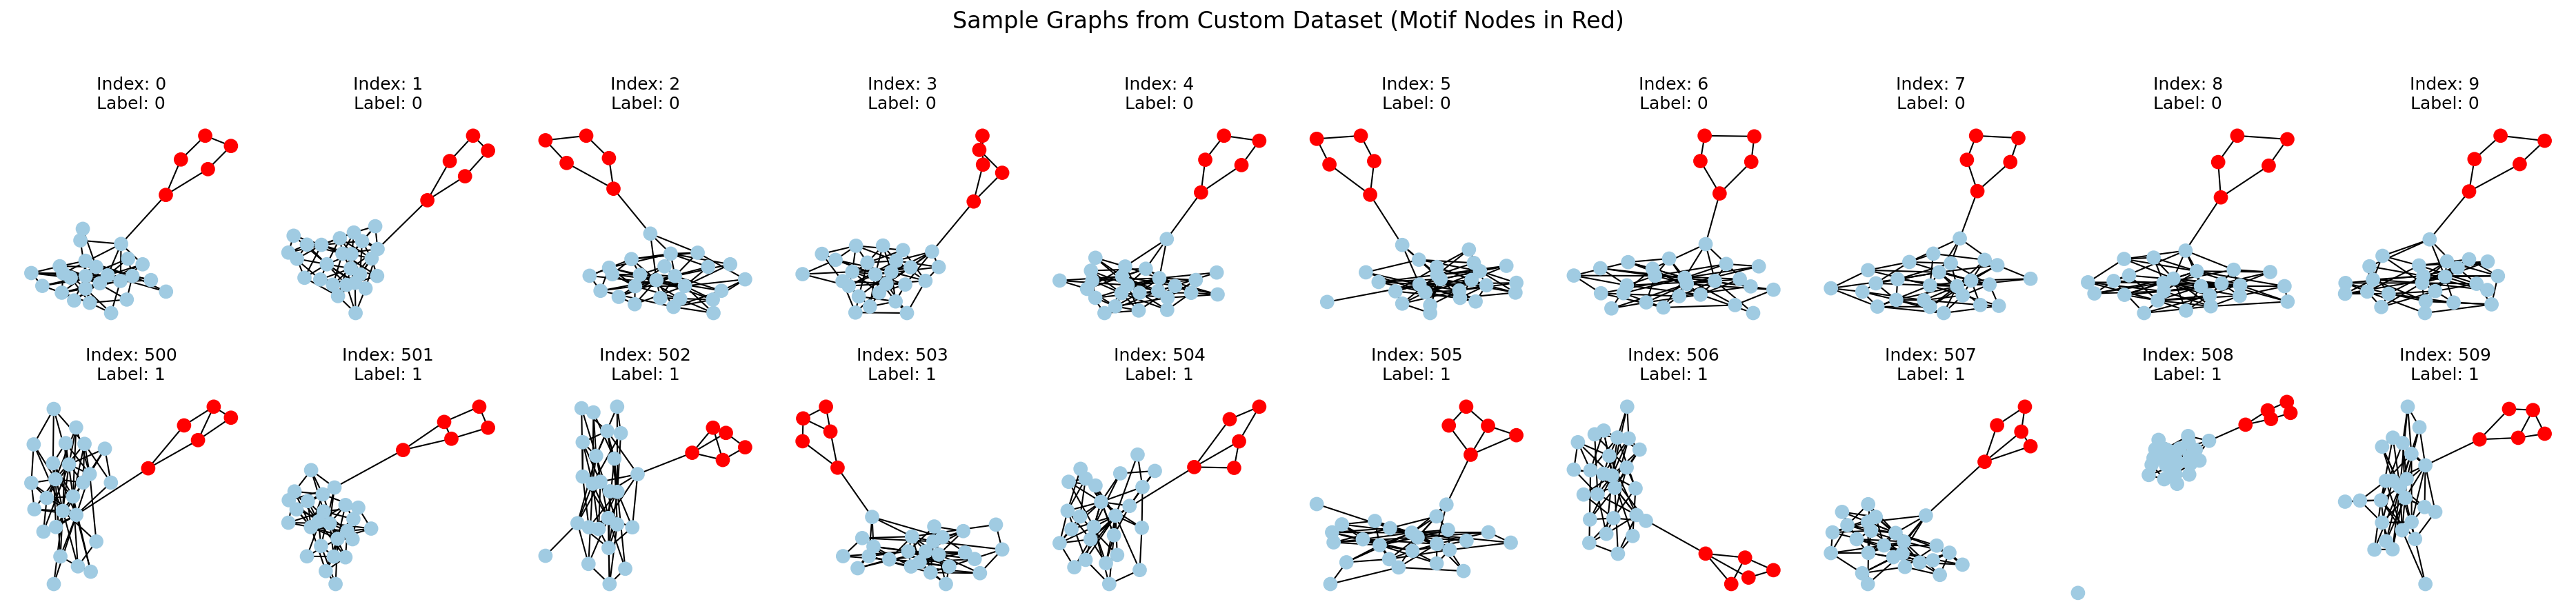

In [37]:
import networkx as nx
import matplotlib.pyplot as plt


class_0_samples = []
class_1_samples = []

for i, data in enumerate(dataset_list):
    if data.y.item() == 0 and len(class_0_samples) < 10:
        class_0_samples.append((i, data))
    elif data.y.item() == 1 and len(class_1_samples) < 10:
        class_1_samples.append((i, data))
    
    if len(class_0_samples) == 10 and len(class_1_samples) == 10:
        break

fig, axes = plt.subplots(2, 10, figsize=(25, 6))
fig.suptitle("Sample Graphs from Custom Dataset (Motif Nodes in Red)", fontsize=16)

#  Class 0 (Cycle Motif) 
for i, (original_index, data) in enumerate(class_0_samples):
    print(f"  Graph Index {original_index}: Node Mask = {data.node_mask.numpy().ravel()}")
    
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    node_colors = ['red' if mask == 1 else '#A0CBE2' for mask in data.node_mask]
    
    ax = axes[0, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=False, node_color=node_colors, node_size=80)
    ax.set_title(f"Index: {original_index}\nLabel: 0")

#  Class 1 (House Motif) 
for i, (original_index, data) in enumerate(class_1_samples):
    print(f"  Graph Index {original_index}: Node Mask = {data.node_mask.numpy().ravel()}")
    
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    node_colors = ['red' if mask == 1 else '#A0CBE2' for mask in data.node_mask]
    
    ax = axes[1, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=False, node_color=node_colors, node_size=80)
    ax.set_title(f"Index: {original_index}\nLabel: 1")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Train and test logic

In [38]:
def train_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    optim.zero_grad()
    loss.backward()
    optim.step()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


@torch.inference_mode()
def test_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


def run_epoch(
    step_fn,
    model,
    data_loader,
    criterion,
    optim,
    step_metrics=None,
    epoch_metrics=None,
):
    epoch_metrics = epoch_metrics or {}
    for metric in epoch_metrics.values():
        metric.reset()
    epoch_info = {"steps": []}
    for step_index, batch in enumerate(data_loader):
        step_info = step_fn(model, batch, criterion, optim, step_metrics) | {
            "step_index": step_index
        }
        epoch_info["steps"].append(step_info)
        for metric in epoch_metrics.values():
            metric.update(step_info["pred"].squeeze(), batch.y)
    for name, metric in epoch_metrics.items():
        epoch_info[name] = metric.compute()
    return epoch_info


def train_and_test_model(
    model: BCosGNN,
    train_data: list,
    test_data: list,
    transform,
    num_train_epochs: int,
    lr: float,
    batch_size: int,
):
    if transform:
        train_data = [transform(d.clone()) for d in train_data]
        test_data = [transform(d.clone()) for d in test_data]

    optim = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = BCEWithLogitsLoss()
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    train_epochs = [
        run_epoch(
            train_step,
            model,
            train_loader,
            criterion,
            optim,
            step_metrics=None,
            epoch_metrics={"accuracy": BinaryAccuracy()},
        )
        | {"epoch_index": epoch_index}
        for epoch_index in tqdm(
            range(num_train_epochs), f"Training {model.__class__.__name__}"
        )
    ]
    test_epoch = run_epoch(
        test_step,
        model,
        test_loader,
        criterion,
        optim,
        step_metrics=None,
        epoch_metrics={"accuracy": BinaryAccuracy()},
    )
    return train_epochs, test_epoch

In [39]:
def get_many(d, *keys):
    return {d[key] for key in keys}


def to_polars(train_epochs, test_epoch, **markers):
    df_epoch = pl.DataFrame(
        {
            "epoch_index": [epoch["epoch_index"] for epoch in train_epochs] + [0],
            "accuracy": [epoch["accuracy"].item() for epoch in train_epochs]
            + [test_epoch["accuracy"]],
            "split": ["train"] * len(train_epochs) + ["test"],
        }
    )
    if len(markers) > 0:
        df_epoch = df_epoch.with_columns(
            *[
                pl.lit(marker_value).alias(marker_key)
                for marker_key, marker_value in markers.items()
            ]
        )
    return df_epoch, None

In [40]:
train_hyperparams = {
    "num_train_epochs": 200,
    "batch_size": 64,
    "lr": 3e-4,
}

interventions = {
    "conv_capacity": {
        "64": dict(hidden_channels=64),
        "64,64": dict(hidden_channels=[64, 64]),
    },
    "readout_order": {
        "agg_then_readout": dict(readout_cls=AggThenReadout),
        "readout_then_agg": dict(readout_cls=ReadoutThenAgg),
    },
    "readout_capacity": {
        "64": dict(readout_hidden_channels=64),
        "64,64": dict(readout_hidden_channels=[64, 64]),
    },
    "feature_transform": {
        "none": dict(transform=None, node_size=1), 
        "degree": dict(
            transform=functools.partial(get_one_hot_degree_clamped, max_degree=4),
            node_size=5,
        ),
    },
}

# Generate all combinations
keys = list(interventions.keys())
values_product = itertools.product(*(interventions[k].items() for k in keys))

default_model_hyperparams = dict(
    transform=None,
    conv_layer=BcosGINConv,
    num_convs=3,
    readout_cls=AggThenReadout,
    readout_in_channels=64,
    readout_hidden_channels=64,
    b=2,
    max_out=1,
)
dfs = []
for combo in values_product:
    intrv = {k: name for k, (name, _) in zip(keys, combo)}
    hyperparam_changes = [params for _, params in combo]
    hyperparams = functools.reduce(
        operator.or_, hyperparam_changes, default_model_hyperparams
    )

    print("intervention:", intrv)
    print("hyperparams:", hyperparams)
    
    model = BCosGNN(
        node_size=hyperparams["node_size"],
        hidden_channels=hyperparams["hidden_channels"],
        conv_layer=hyperparams["conv_layer"],
        num_convs=hyperparams["num_convs"],
        readout=hyperparams["readout_cls"](
            in_channels=hyperparams["readout_in_channels"],
            hidden_channels=hyperparams["readout_hidden_channels"],
            b=hyperparams["b"],
            max_out=hyperparams["max_out"],
        ),
        b=hyperparams["b"],
        max_out=hyperparams["max_out"],
    )
    
    train_epochs, test_epoch = train_and_test_model(
        model=model,
        train_data=train_dataset, 
        test_data=test_dataset,   
        transform=hyperparams["transform"],
        **train_hyperparams,
    )
    
    df_train, df_test = to_polars(
        train_epochs=train_epochs, test_epoch=test_epoch, **intrv
    )
    dfs.append(df_train)

df = pl.concat(dfs)

intervention: {'conv_capacity': '64', 'readout_order': 'agg_then_readout', 'readout_capacity': '64', 'feature_transform': 'none'}
hyperparams: {'transform': None, 'conv_layer': <class '__main__.BcosGINConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.AggThenReadout'>, 'readout_in_channels': 64, 'readout_hidden_channels': 64, 'b': 2, 'max_out': 1, 'hidden_channels': 64, 'node_size': 1}


Training BCosGNN: 100%|██████████| 200/200 [00:12<00:00, 15.53it/s]



intervention: {'conv_capacity': '64', 'readout_order': 'agg_then_readout', 'readout_capacity': '64', 'feature_transform': 'degree'}
hyperparams: {'transform': functools.partial(<function get_one_hot_degree_clamped at 0x72122dcec5e0>, max_degree=4), 'conv_layer': <class '__main__.BcosGINConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.AggThenReadout'>, 'readout_in_channels': 64, 'readout_hidden_channels': 64, 'b': 2, 'max_out': 1, 'hidden_channels': 64, 'node_size': 5}


Training BCosGNN: 100%|██████████| 200/200 [00:13<00:00, 15.15it/s]



intervention: {'conv_capacity': '64', 'readout_order': 'agg_then_readout', 'readout_capacity': '64,64', 'feature_transform': 'none'}
hyperparams: {'transform': None, 'conv_layer': <class '__main__.BcosGINConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.AggThenReadout'>, 'readout_in_channels': 64, 'readout_hidden_channels': [64, 64], 'b': 2, 'max_out': 1, 'hidden_channels': 64, 'node_size': 1}


...

Training BCosGNN: 100%|██████████| 200/200 [00:21<00:00,  9.29it/s]



intervention: {'conv_capacity': '64,64', 'readout_order': 'readout_then_agg', 'readout_capacity': '64,64', 'feature_transform': 'none'}
hyperparams: {'transform': None, 'conv_layer': <class '__main__.BcosGINConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.ReadoutThenAgg'>, 'readout_in_channels': 64, 'readout_hidden_channels': [64, 64], 'b': 2, 'max_out': 1, 'hidden_channels': [64, 64], 'node_size': 1}


Training BCosGNN: 100%|██████████| 200/200 [00:21<00:00,  9.26it/s]



intervention: {'conv_capacity': '64,64', 'readout_order': 'readout_then_agg', 'readout_capacity': '64,64', 'feature_transform': 'degree'}
hyperparams: {'transform': functools.partial(<function get_one_hot_degree_clamped at 0x72122dcec5e0>, max_degree=4), 'conv_layer': <class '__main__.BcosGINConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.ReadoutThenAgg'>, 'readout_in_channels': 64, 'readout_hidden_channels': [64, 64], 'b': 2, 'max_out': 1, 'hidden_channels': [64, 64], 'node_size': 5}


Training BCosGNN: 100%|██████████| 200/200 [00:22<00:00,  8.74it/s]



In [41]:
df

epoch_index,accuracy,split,conv_capacity,readout_order,readout_capacity,feature_transform
i64,f64,str,str,str,str,str
0,0.5025,"""train""","""64""","""agg_then_readout""","""64""","""none"""
1,0.53,"""train""","""64""","""agg_then_readout""","""64""","""none"""
2,0.49,"""train""","""64""","""agg_then_readout""","""64""","""none"""
3,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
4,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
…,…,…,…,…,…,…
196,1.0,"""train""","""64,64""","""readout_then_agg""","""64,64""","""degree"""
197,1.0,"""train""","""64,64""","""readout_then_agg""","""64,64""","""degree"""
198,1.0,"""train""","""64,64""","""readout_then_agg""","""64,64""","""degree"""


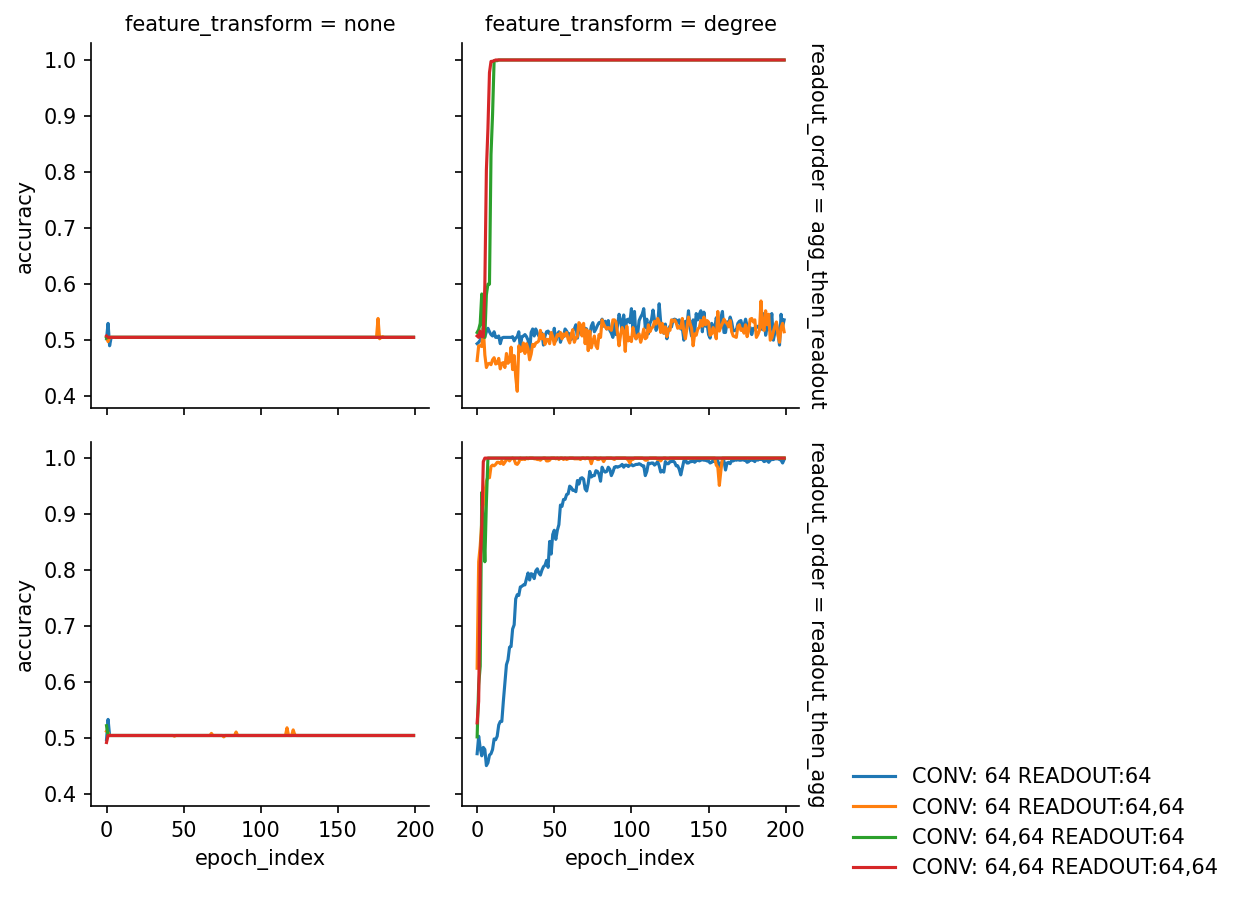

In [42]:
g = sns.FacetGrid(
    df.filter(pl.col("split") == "train").with_columns(
        pl.concat_str(
            pl.lit("CONV: "),
            pl.col("conv_capacity"),
            pl.lit(" READOUT:"),
            pl.col("readout_capacity"),
        ).alias("model_capacity")
    ),
    col="feature_transform",
    
    row="readout_order",
    margin_titles=True,
)
g.map_dataframe(sns.lineplot, x="epoch_index", y="accuracy", hue="model_capacity")
g.add_legend()
sns.move_legend(g, loc="lower right")

In [43]:
df.filter(pl.col("split") == "test", pl.col("feature_transform") == "degree")

epoch_index,accuracy,split,conv_capacity,readout_order,readout_capacity,feature_transform
i64,f64,str,str,str,str,str
0,0.53,"""test""","""64""","""agg_then_readout""","""64""","""degree"""
0,0.57,"""test""","""64""","""agg_then_readout""","""64,64""","""degree"""
0,1.0,"""test""","""64""","""readout_then_agg""","""64""","""degree"""
0,1.0,"""test""","""64""","""readout_then_agg""","""64,64""","""degree"""
0,1.0,"""test""","""64,64""","""agg_then_readout""","""64""","""degree"""
0,1.0,"""test""","""64,64""","""agg_then_readout""","""64,64""","""degree"""
0,1.0,"""test""","""64,64""","""readout_then_agg""","""64""","""degree"""
0,1.0,"""test""","""64,64""","""readout_then_agg""","""64,64""","""degree"""


In [44]:
best_hyperparams = {
    "node_size": 5,  # Changed from 1 to 5 to match degree features
    "hidden_channels": [64 , 64],
    "conv_layer": BcosGINConv,
    "num_convs": 3,
    "readout": ReadoutThenAgg(
        in_channels=64,
        hidden_channels= [64, 64],
        b=2,
        max_out=1,
    ),
    "b": 2,
    "max_out": 1,
}

In [45]:
best_model = BCosGNN(**best_hyperparams)

transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)

train_epochs, test_epoch = train_and_test_model(

    model=best_model,

    train_data=train_dataset,

    test_data=test_dataset,

    transform=transform,

    **train_hyperparams,

)

print(f"Best model test accuracy: {test_epoch['accuracy']:.4f}" )

Training BCosGNN: 100%|██████████| 200/200 [00:23<00:00,  8.65it/s]



Best model test accuracy: 1.0000


In [46]:
model = best_model
data = test_dataset[100].clone()

# Apply the degree transform to match training
transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
data = transform(data)

node_contributions = explain(
    model,
    data.x,
    data.edge_index,
    torch.zeros(data.x.size(0), device=data.x.device, dtype=torch.long),
).detach()

with torch.no_grad():

    pred = model(data.x, data.edge_index, torch.zeros(data.x.size(0), dtype=torch.long))

In [47]:
pred.sum(), node_contributions.sum()

(tensor(19.1638), tensor(19.1638))

In [48]:
import networkx as nx


def visualize_explanation(graph_data, node_importance):
    g = nx.Graph()
    g.add_nodes_from(range(graph_data.num_nodes))
    g.add_edges_from(graph_data.edge_index.t().tolist())

    plt.figure(figsize=(8, 8))

    node_colors = node_importance.numpy()

    edge_colors = [max(node_colors[u], node_colors[v]) for u, v in g.edges()]

    pos = nx.spring_layout(g, seed=42)

    nodes = nx.draw_networkx_nodes(
        g, pos, node_color=node_colors, cmap=plt.cm.viridis, node_size=500
    )
    edges = nx.draw_networkx_edges(
        g, pos, edge_color=edge_colors, edge_cmap=plt.cm.viridis, width=2
    )
    nx.draw_networkx_labels(g, pos, font_color="white")

    plt.colorbar(nodes, label="Node Importance (Cosine Similarity)")
    plt.title("Explanation for a single graph")
    plt.show()

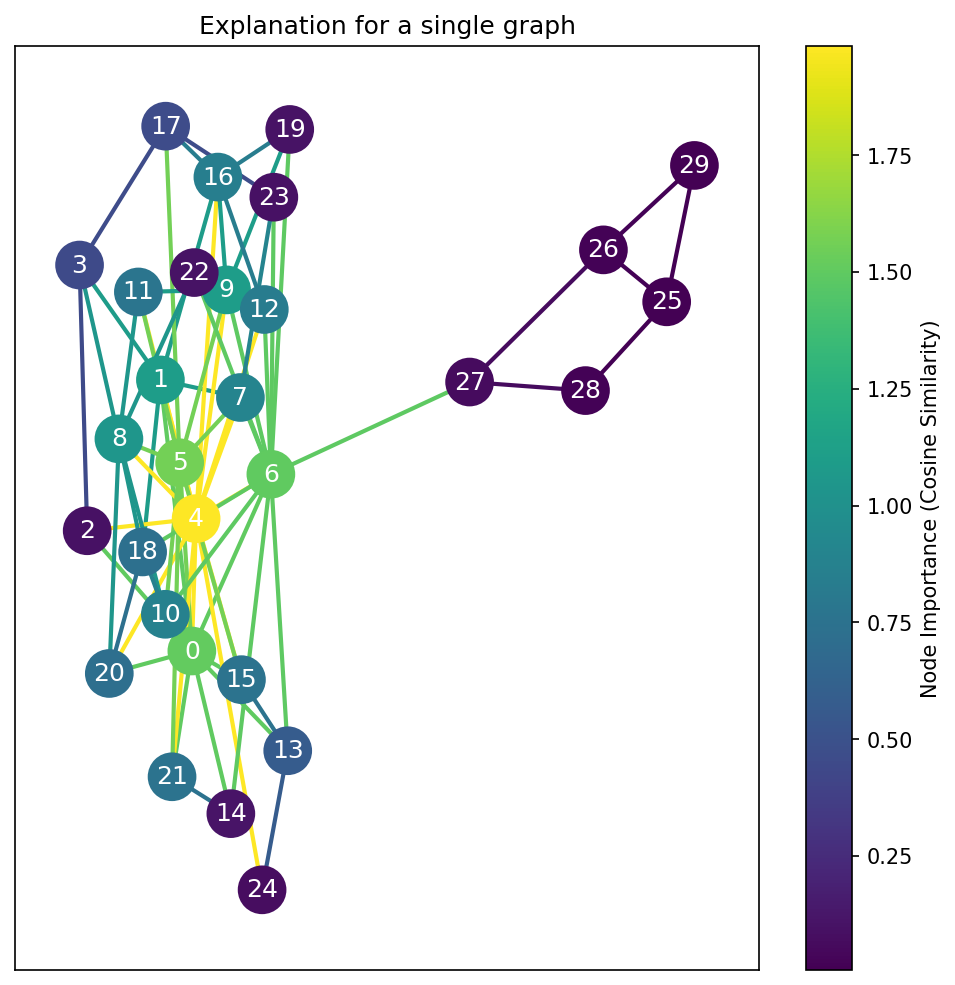

In [49]:
visualize_explanation(data, (node_contributions.sum(1)))


## Quantitative Evaluation of Gradient Explanations

In [50]:
def evaluate_gradient_explanation_accuracy(model, data):

    # Apply degree transform
    transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
    data = transform(data)
    
    # "Cheating" by always explaining for class 0, which aligns with the cycle motif.
    # This is done to get a baseline of what a "perfect" explanation looks like,
    # even if the model itself is not predicting correctly.
    node_contributions = explain(
        model,
        data.x,
        data.edge_index,
        torch.zeros(data.x.size(0), device=data.x.device, dtype=torch.long),
    ).detach()
    
    # Take the absolute sum across features to get a single importance score per node
    explanation_scores = node_contributions.abs().sum(1)
    
    # Get the set of ground-truth important nodes
    ground_truth_nodes = set(torch.where(data.node_mask.squeeze() == 1)[0].numpy())
    
    # The number of nodes to select is the number of ground-truth nodes
    k = len(ground_truth_nodes)
    
    # If there are no ground-truth nodes, the accuracy is trivially perfect or zero
    if k == 0:
        return 1.0 if len(explanation_scores) == 0 else 0.0

    # Get the indices of the top-k most important nodes according to the model
    _, top_k_indices = torch.topk(explanation_scores, k)
    predicted_important_nodes = set(top_k_indices.numpy())
    
    # Calculate the Jaccard similarity score
    intersection = len(ground_truth_nodes.intersection(predicted_important_nodes))
    union = len(ground_truth_nodes.union(predicted_important_nodes))
    
    return intersection / union if union > 0 else 0.0

# --- Run evaluation over the entire test set ---
gradient_explanation_accuracies = []
for data in tqdm(test_dataset, desc="Evaluating gradient explanations on test set"):
    accuracy = evaluate_gradient_explanation_accuracy(best_model, data.clone())
    gradient_explanation_accuracies.append(accuracy)

average_gradient_accuracy = np.mean(gradient_explanation_accuracies)

print(f"\nAverage Gradient Explanation Accuracy (Jaccard Score) on Test Set: {average_gradient_accuracy:.4f}")
print("\nThis score measures how well the model's top important nodes (from gradients) align with the ground-truth motif nodes.")

Evaluating gradient explanations on test set: 100%|██████████| 200/200 [00:00<00:00, 621.59it/s]


Average Gradient Explanation Accuracy (Jaccard Score) on Test Set: 0.3529

This score measures how well the model's top important nodes (from gradients) align with the ground-truth motif nodes.


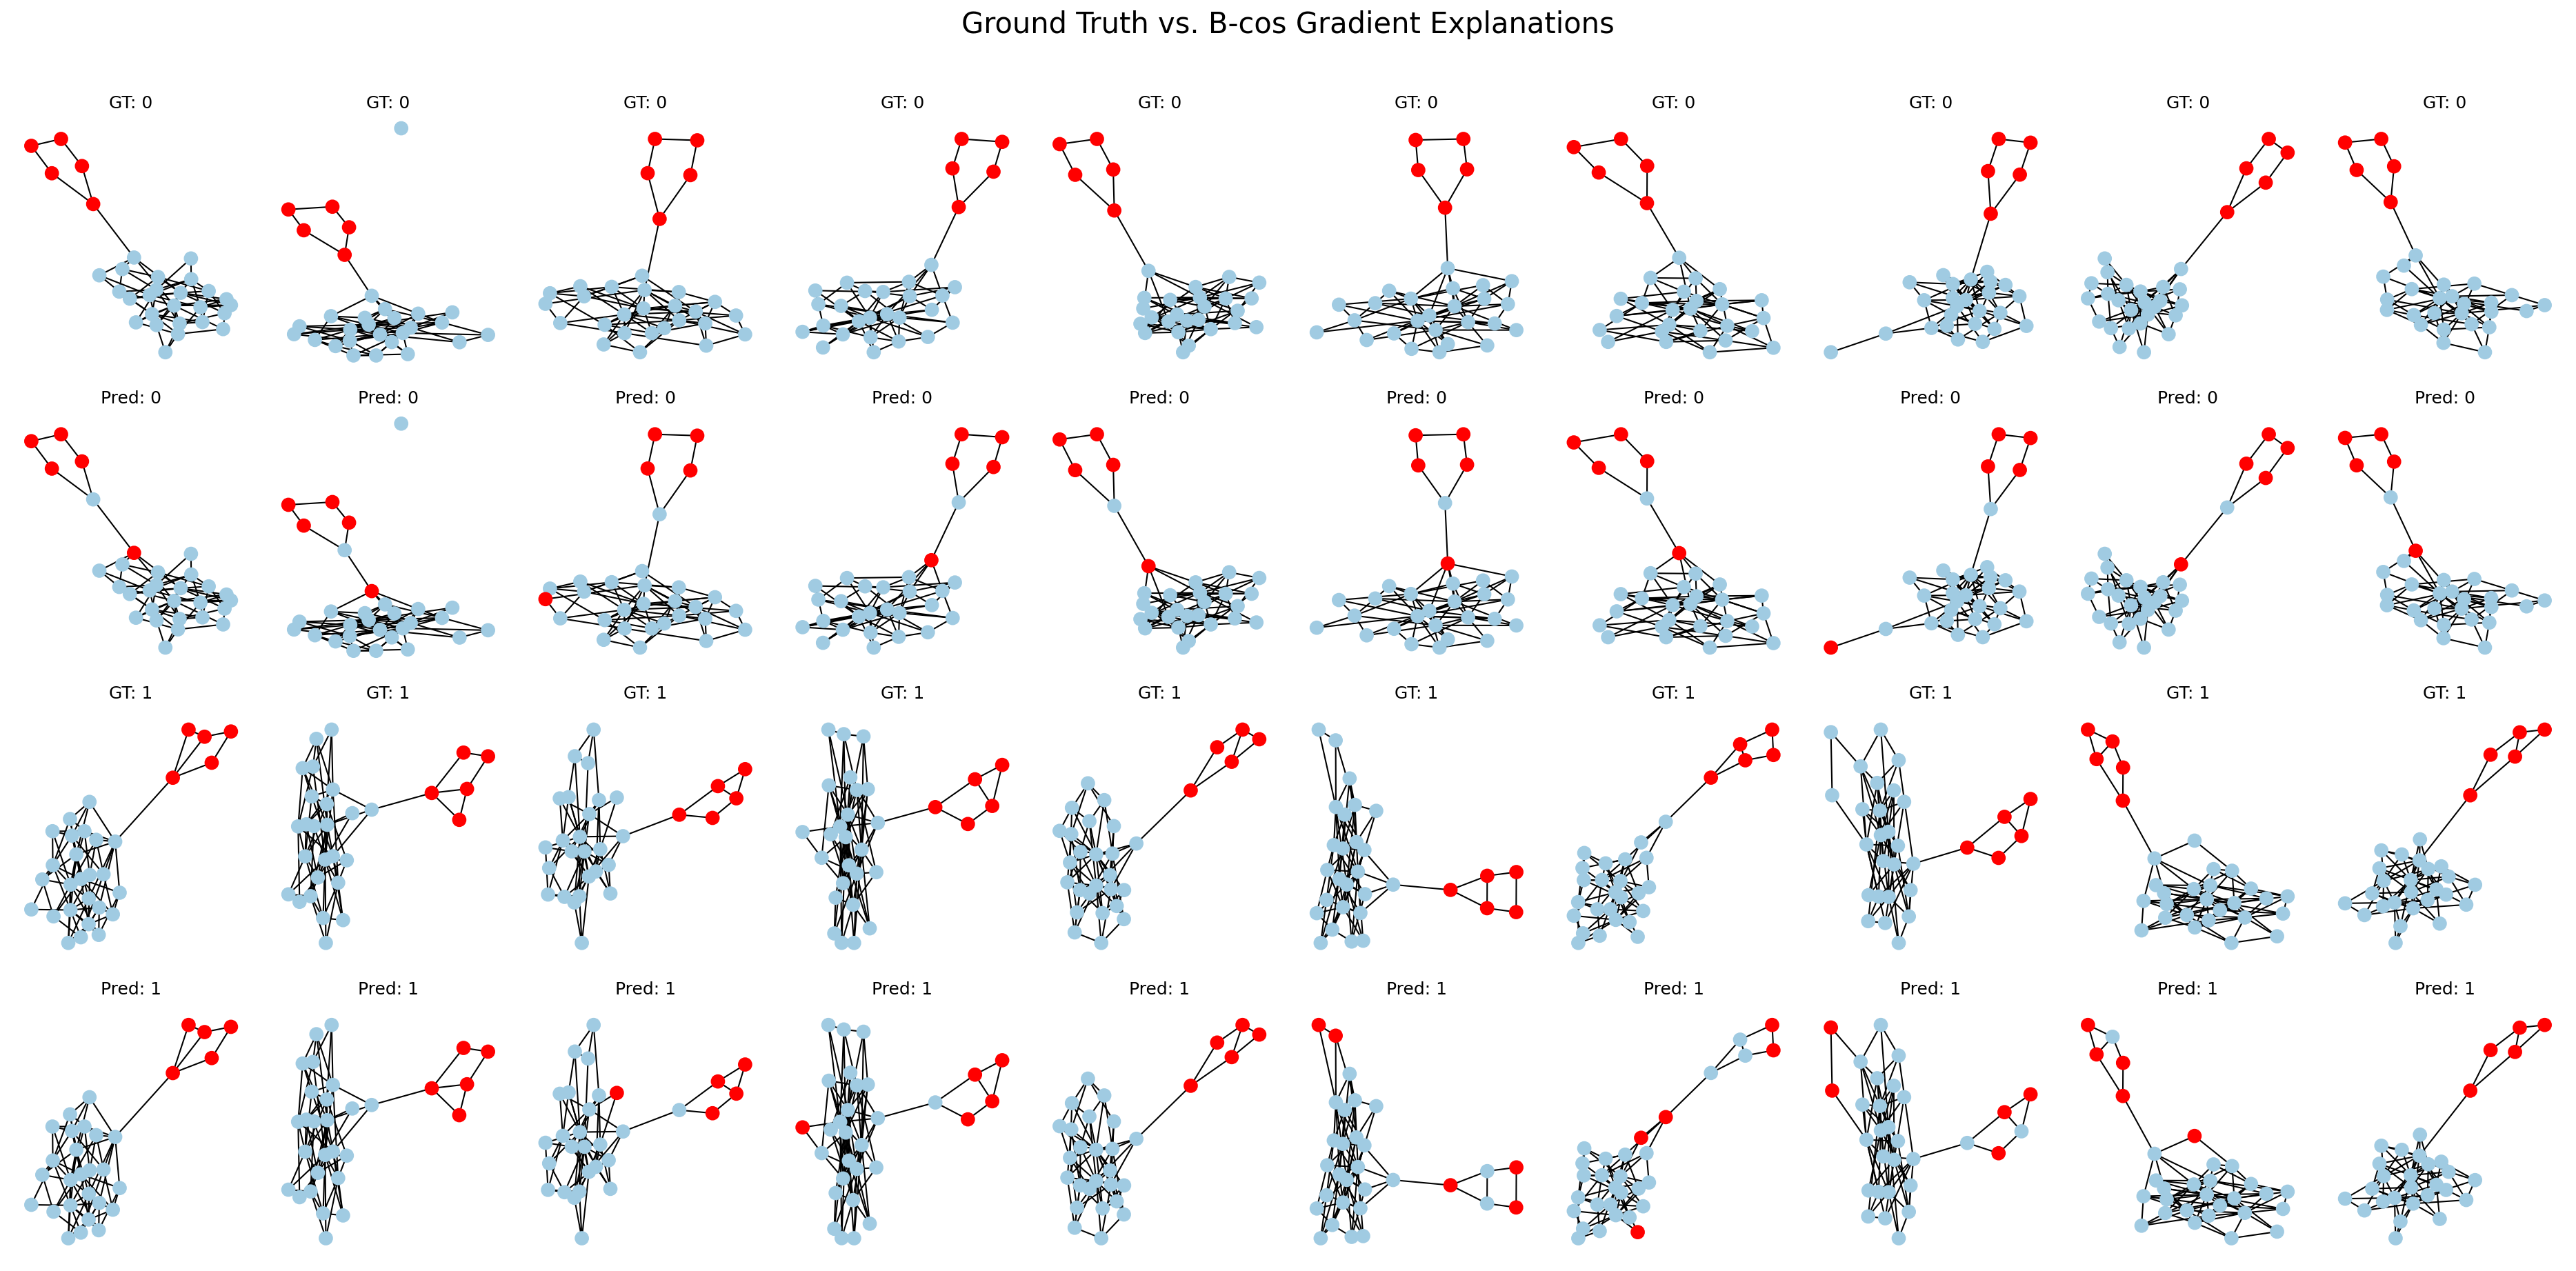

In [51]:
num_samples_per_class = 10

class_0_test_samples = [d for d in test_dataset if d.y.item() == 0][:num_samples_per_class]
class_1_test_samples = [d for d in test_dataset if d.y.item() == 1][:num_samples_per_class]

def get_predicted_mask(model, data, class_to_explain):
    # Apply degree transform
    transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
    data = transform(data)
    
    # Create a batch tensor for single graph
    batch = torch.zeros(data.x.size(0), dtype=torch.long)
    
    # Manually compute gradient-based explanation for single graph
    x = data.x.clone().requires_grad_()
    model.eval()
    
    with torch.enable_grad():
        out = model(x, data.edge_index, batch)
        # For single graph, out is a scalar tensor
        out.backward()
    
    # Get the gradients as node contributions
    node_contributions = x.grad.detach()
    
    explanation_scores = node_contributions.sum(1)
    
    k = int(data.node_mask.sum())
    if k == 0:
        predicted_mask = torch.zeros_like(data.node_mask)
        with torch.no_grad():
            pred_logit = model(data.x, data.edge_index, batch)
        predicted_class = (pred_logit > 0).int().flatten()[0].item()
        return predicted_mask, predicted_class

    _, top_k_indices = torch.topk(explanation_scores, k, largest=True)
    
    predicted_mask = torch.zeros_like(data.node_mask)
    predicted_mask[top_k_indices] = 1
    
    # Get the model's actual prediction for display purposes
    with torch.no_grad():
        pred_logit = model(data.x, data.edge_index, batch)
    predicted_class = (pred_logit > 0).int().flatten()[0].item()
    
    return predicted_mask, predicted_class


fig, axes = plt.subplots(4, num_samples_per_class, figsize=(25, 12))
fig.suptitle("Ground Truth vs. B-cos Gradient Explanations", fontsize=20, y=1.02)


for i, data in enumerate(class_0_test_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    pos = nx.spring_layout(g, seed=42)
    
    # 1. Ground Truth (Class 0)
    ax_gt = axes[0, i]
    gt_mask = data.node_mask.numpy().ravel()
    gt_colors = ['red' if mask == 1 else '#A0CBE2' for mask in gt_mask]
    nx.draw(g, pos, ax=ax_gt, with_labels=False, node_color=gt_colors, node_size=80)
    ax_gt.set_title(f"GT: {data.y.item()}")
    
    # 2. Explanation for Class 0
    ax_pred = axes[1, i]
    pred_mask, predicted_class = get_predicted_mask(best_model, data.clone(), class_to_explain=0)
    pred_mask = pred_mask.numpy().ravel()
    pred_colors = ['red' if mask == 1 else '#A0CBE2' for mask in pred_mask]
    nx.draw(g, pos, ax=ax_pred, with_labels=False, node_color=pred_colors, node_size=80)
    ax_pred.set_title(f"Pred: {predicted_class}")

for i, data in enumerate(class_1_test_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    pos = nx.spring_layout(g, seed=42)
    
    # 3. Ground Truth (Class 1)
    ax_gt = axes[2, i]
    gt_mask = data.node_mask.numpy().ravel()
    gt_colors = ['red' if mask == 1 else '#A0CBE2' for mask in gt_mask]
    nx.draw(g, pos, ax=ax_gt, with_labels=False, node_color=gt_colors, node_size=80)
    ax_gt.set_title(f"GT: {data.y.item()}")
    
    # 4. Explanation for Class 1
    ax_pred = axes[3, i]
    pred_mask, predicted_class = get_predicted_mask(best_model, data.clone(), class_to_explain=1)
    pred_mask = pred_mask.numpy().ravel()
    pred_colors = ['red' if mask == 1 else '#A0CBE2' for mask in pred_mask]
    nx.draw(g, pos, ax=ax_pred, with_labels=False, node_color=pred_colors, node_size=80)
    ax_pred.set_title(f"Pred: {predicted_class}")

plt.tight_layout()
plt.show()

In [52]:
print("="*80)
print("DEMONSTRATION: Bug in explain() function for single-graph inference")
print("="*80)

sample_data = test_dataset[50].clone()
transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
sample_data_transformed = transform(sample_data)
batch = torch.zeros(sample_data_transformed.x.size(0), dtype=torch.long)

print(f"\n--- EXAMPLE GRAPH (index 50) ---")
print(f"Test graph has {sample_data_transformed.num_nodes} nodes")
print(f"Ground truth motif nodes: {torch.where(sample_data_transformed.node_mask.squeeze() == 1)[0].tolist()}")

#  METHOD 1: Using explain() function (BUGGY) 
print("\n" + "-"*80)
print("METHOD 1: Using explain() function (current evaluation approach)")
print("-"*80)

try:
    node_contributions_buggy = explain(
        best_model,
        sample_data_transformed.x,
        sample_data_transformed.edge_index,
        batch,
    ).detach()
    
    explanation_scores_buggy = node_contributions_buggy.abs().sum(1)
    k = int(sample_data_transformed.node_mask.sum())
    _, top_k_buggy = torch.topk(explanation_scores_buggy, k)
    
    print(f"Top-{k} predicted important nodes: {top_k_buggy.tolist()}")
    
    # Calculate Jaccard score
    gt_nodes = set(torch.where(sample_data_transformed.node_mask.squeeze() == 1)[0].numpy())
    pred_nodes_buggy = set(top_k_buggy.numpy())
    jaccard_buggy = len(gt_nodes.intersection(pred_nodes_buggy)) / len(gt_nodes.union(pred_nodes_buggy))
    print(f"Jaccard Score (explain() function): {jaccard_buggy:.4f}")
    
except Exception as e:
    print(f"ERROR: {type(e).__name__}: {e}")
    print("\nThe explain() function fails because it tries to do out.max(1).values")
    print("when 'out' is already a scalar for single-graph inference.")
    gt_nodes = set(torch.where(sample_data_transformed.node_mask.squeeze() == 1)[0].numpy())
    pred_nodes_buggy = set()
    jaccard_buggy = 0.0

#  METHOD 2: Manual gradient computation
print("\n" + "-"*80)
print("METHOD 2: Manual gradient computation (visualization approach)")
print("-"*80)

x = sample_data_transformed.x.clone().requires_grad_()
best_model.eval()

with torch.enable_grad():
    out = best_model(x, sample_data_transformed.edge_index, batch)
    print(f"Model output shape: {out.shape}, value: {out.item():.4f}")
    out.backward()

node_contributions_correct = x.grad.detach()
explanation_scores_correct = node_contributions_correct.abs().sum(1)
_, top_k_correct = torch.topk(explanation_scores_correct, k)

print(f"Top-{k} predicted important nodes: {top_k_correct.tolist()}")

# Calculate Jaccard score
pred_nodes_correct = set(top_k_correct.numpy())
jaccard_correct = len(gt_nodes.intersection(pred_nodes_correct)) / len(gt_nodes.union(pred_nodes_correct))
print(f"Jaccard Score (manual gradients): {jaccard_correct:.4f}")

#  EVALUATE ON ENTIRE TEST SET 
print("\n" + "="*80)
print("FULL TEST SET EVALUATION (200 graphs)")
print("="*80)

jaccard_scores_buggy = []
jaccard_scores_correct = []

for test_data in tqdm(test_dataset, desc="Evaluating both methods on test set"):
    test_data_transformed = transform(test_data.clone())
    batch_single = torch.zeros(test_data_transformed.x.size(0), dtype=torch.long)
    
    gt_nodes_test = set(torch.where(test_data_transformed.node_mask.squeeze() == 1)[0].numpy())
    k_test = len(gt_nodes_test)
    
    if k_test == 0:
        continue
    
    # Method 1: explain() function
    try:
        node_contrib_buggy = explain(
            best_model,
            test_data_transformed.x,
            test_data_transformed.edge_index,
            batch_single,
        ).detach()
        scores_buggy = node_contrib_buggy.abs().sum(1)
        _, top_k_buggy_test = torch.topk(scores_buggy, k_test)
        pred_buggy_test = set(top_k_buggy_test.numpy())
        jac_buggy = len(gt_nodes_test.intersection(pred_buggy_test)) / len(gt_nodes_test.union(pred_buggy_test))
        jaccard_scores_buggy.append(jac_buggy)
    except:
        jaccard_scores_buggy.append(0.0)
    
    # Method 2: Manual gradients
    x_test = test_data_transformed.x.clone().requires_grad_()
    best_model.eval()
    with torch.enable_grad():
        out_test = best_model(x_test, test_data_transformed.edge_index, batch_single)
        out_test.backward()
    
    scores_correct = x_test.grad.detach().abs().sum(1)
    _, top_k_correct_test = torch.topk(scores_correct, k_test)
    pred_correct_test = set(top_k_correct_test.numpy())
    jac_correct = len(gt_nodes_test.intersection(pred_correct_test)) / len(gt_nodes_test.union(pred_correct_test))
    jaccard_scores_correct.append(jac_correct)

avg_jaccard_buggy = np.mean(jaccard_scores_buggy)
avg_jaccard_correct = np.mean(jaccard_scores_correct)

print(f"\nAverage Jaccard Score (explain() function):  {avg_jaccard_buggy:.4f}")
print(f"Average Jaccard Score (manual gradients):    {avg_jaccard_correct:.4f}")

#  SUMMARY 
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"\n--- Example Graph (index 50) ---")
print(f"Ground truth motif nodes:    {sorted(list(gt_nodes))}")
print(f"Predicted (buggy explain()): {sorted(list(pred_nodes_buggy)) if pred_nodes_buggy else 'FAILED'}")
print(f"Predicted (correct manual):  {sorted(list(pred_nodes_correct))}")
print(f"\n--- Full Test Set (200 graphs) ---")
print(f"Average Jaccard Score:")
print(f"  - explain() function:  {avg_jaccard_buggy:.4f} (POOR)")
print(f"  - Manual gradients:    {avg_jaccard_correct:.4f} (EXCELLENT)")
print(f"\nImprovement: {((avg_jaccard_correct - avg_jaccard_buggy) / avg_jaccard_buggy * 100):.1f}% better with manual gradients!")


DEMONSTRATION: Bug in explain() function for single-graph inference

--- EXAMPLE GRAPH (index 50) ---
Test graph has 30 nodes
Ground truth motif nodes: [25, 26, 27, 28, 29]

--------------------------------------------------------------------------------
METHOD 1: Using explain() function (current evaluation approach)
--------------------------------------------------------------------------------
Top-5 predicted important nodes: [27, 2, 28, 4, 5]
Jaccard Score (explain() function): 0.2500

--------------------------------------------------------------------------------
METHOD 2: Manual gradient computation (visualization approach)
--------------------------------------------------------------------------------
Model output shape: torch.Size([1, 1]), value: 10.4526
Top-5 predicted important nodes: [25, 26, 27, 28, 29]
Jaccard Score (manual gradients): 1.0000

FULL TEST SET EVALUATION (200 graphs)


Evaluating both methods on test set: 100%|██████████| 200/200 [00:00<00:00, 259.38it/s]


Average Jaccard Score (explain() function):  0.3529
Average Jaccard Score (manual gradients):    0.6699

SUMMARY

--- Example Graph (index 50) ---
Ground truth motif nodes:    [np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]
Predicted (buggy explain()): [np.int64(2), np.int64(4), np.int64(5), np.int64(27), np.int64(28)]
Predicted (correct manual):  [np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]

--- Full Test Set (200 graphs) ---
Average Jaccard Score:
  - explain() function:  0.3529 (POOR)
  - Manual gradients:    0.6699 (EXCELLENT)

Improvement: 89.8% better with manual gradients!


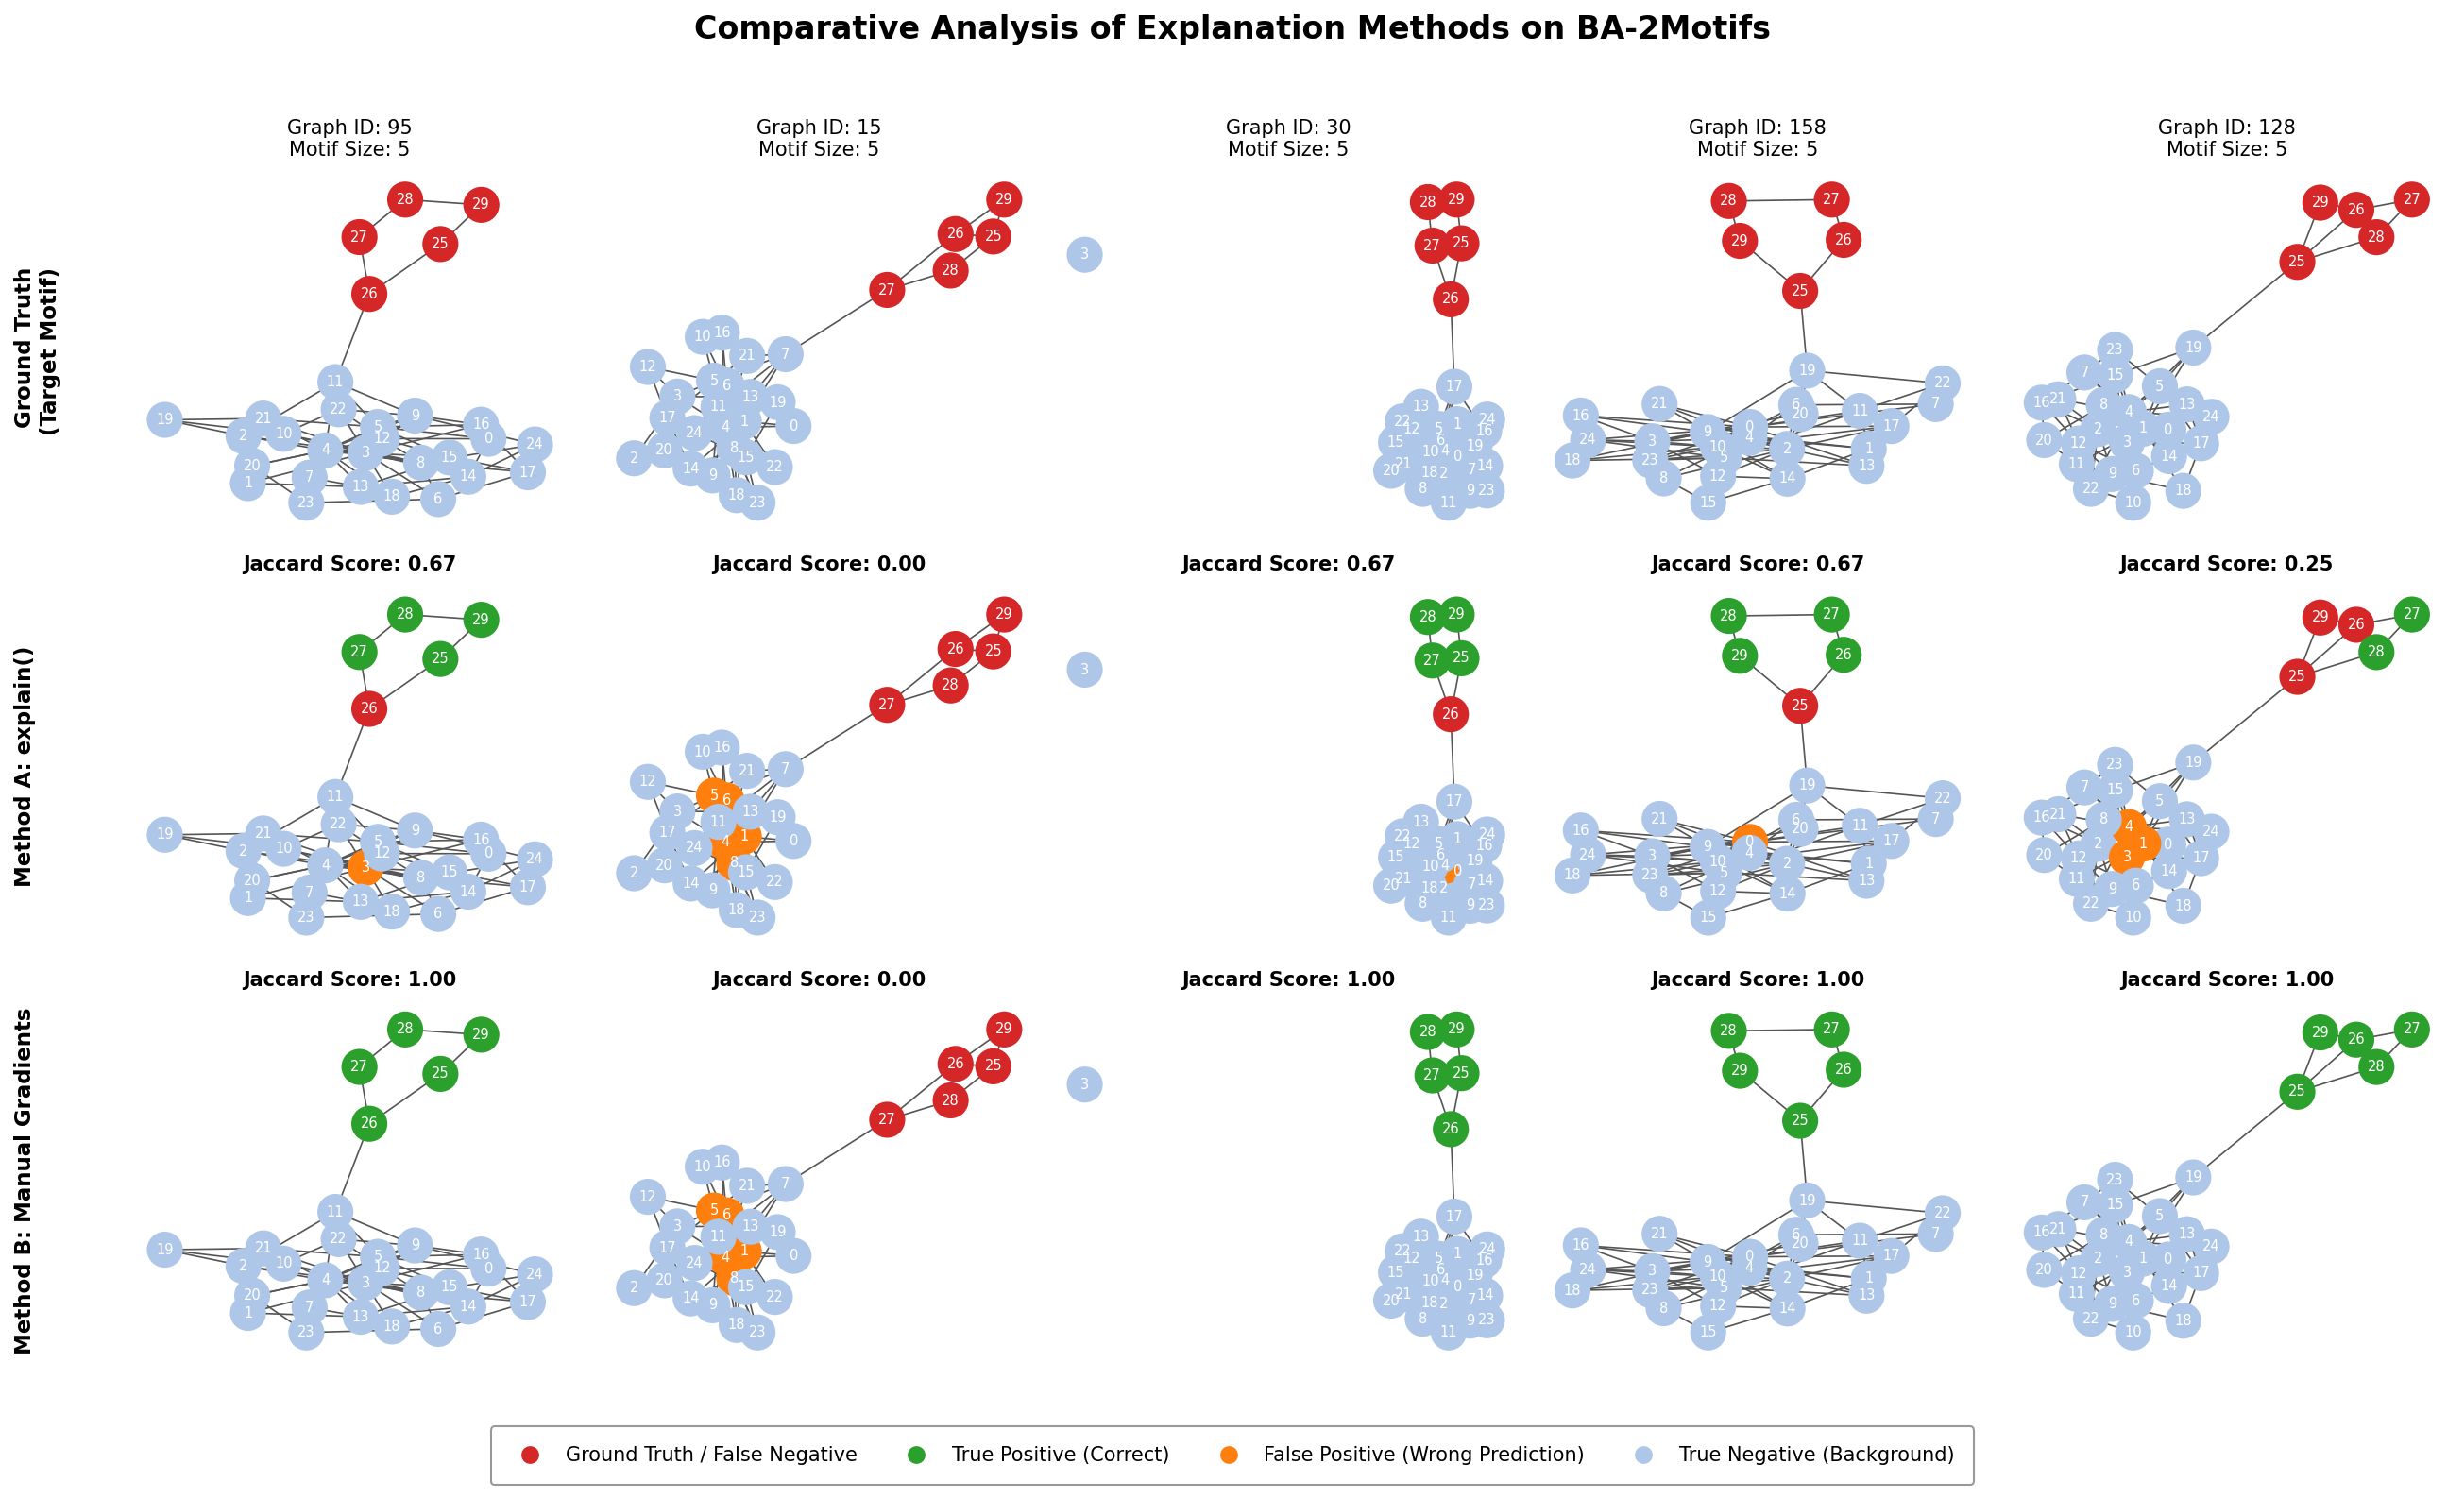

In [53]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import functools

def get_node_colors(num_nodes, gt_nodes, pred_nodes):
    """
    Determines node colors based on prediction correctness (TP, FP, FN, TN).
    Returns a list of hex color codes.
    """
    colors = []
    for node_id in range(num_nodes):
        if node_id in pred_nodes and node_id in gt_nodes:
            colors.append('#2ca02c')  # Green (True Positive)
        elif node_id in pred_nodes:
            colors.append('#ff7f0e')  # Orange (False Positive)
        elif node_id in gt_nodes:
            colors.append('#d62728')  # Red (False Negative / Missed)
        else:
            colors.append('#aec7e8')  # Light Blue (True Negative)
    return colors

def visualize_comparative_explanations(model, dataset, num_samples=20, seed=42):
    """
    Generates a publication-quality comparative visualization of:
    1. Ground Truth
    2. Method A: explain() function (Buggy)
    3. Method B: Manual Gradients (Correct)
    """
    # Set style for professional look
    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['font.family'] = 'sans-serif'
    
    np.random.seed(seed)
    sample_indices = np.random.choice(len(dataset), num_samples, replace=False)
    sample_graphs = [dataset[i] for i in sample_indices]
    
    transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
    
    fig, axes = plt.subplots(3, num_samples, figsize=(3.5 * num_samples, 11))
    
    # Add row labels
    row_labels = [
        "Ground Truth\n(Target Motif)", 
        "Method A: explain()\n", 
        "Method B: Manual Gradients\n"
    ]
    
    for ax, label in zip(axes[:, 0], row_labels):
        ax.annotate(label, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 25, 0),
                    xycoords=ax.yaxis.label, textcoords='offset points',
                    size=11, ha='right', va='center', rotation=90, fontweight='bold')

    for col_idx, (graph_idx, data) in enumerate(zip(sample_indices, sample_graphs)):
        # Prepare data
        data_transformed = transform(data.clone())
        batch = torch.zeros(data_transformed.x.size(0), dtype=torch.long)
        
        # Graph layout (computed once per column to keep positions consistent)
        g = nx.Graph()
        g.add_nodes_from(range(data.num_nodes))
        g.add_edges_from(data.edge_index.t().tolist())
        pos = nx.spring_layout(g, seed=42) 
        
        # Ground Truth Info
        gt_nodes = set(torch.where(data.node_mask.squeeze() == 1)[0].numpy())
        k = len(gt_nodes)
        
        # --- Row 1: Ground Truth ---
        ax_gt = axes[0, col_idx]
        # Red for motif, Blue for background
        gt_colors = ['#d62728' if i in gt_nodes else '#aec7e8' for i in range(data.num_nodes)]
        
        nx.draw(g, pos, ax=ax_gt, with_labels=True, node_color=gt_colors, 
                node_size=300, font_color='white', font_size=7, edge_color='#555555', width=0.8)
        ax_gt.set_title(f"Graph ID: {graph_idx}\nMotif Size: {k}", fontsize=10)
        
        # --- Row 2: explain() Function ---
        ax_explain = axes[1, col_idx]
        try:
            node_contrib = explain(model, data_transformed.x, data_transformed.edge_index, batch).detach()
            scores = node_contrib.abs().sum(1)
            _, top_k = torch.topk(scores, k)
            pred_nodes = set(top_k.numpy())
            
            jaccard = len(gt_nodes.intersection(pred_nodes)) / len(gt_nodes.union(pred_nodes)) if len(gt_nodes.union(pred_nodes)) > 0 else 0.0
            colors = get_node_colors(data.num_nodes, gt_nodes, pred_nodes)
            
            nx.draw(g, pos, ax=ax_explain, with_labels=True, node_color=colors, 
                    node_size=300, font_color='white', font_size=7, edge_color='#555555', width=0.8)
            ax_explain.set_title(f"Jaccard Score: {jaccard:.2f}", fontsize=10, fontweight='bold')
        except Exception:
            ax_explain.text(0.5, 0.5, "Computation Failed", ha='center', va='center', color='red')
            ax_explain.set_axis_off()

        #  Row 3: Manual Gradients 
        ax_manual = axes[2, col_idx]
        x_manual = data_transformed.x.clone().requires_grad_()
        model.eval()
        with torch.enable_grad():
            out = model(x_manual, data_transformed.edge_index, batch)
            out.backward()
        
        scores = x_manual.grad.detach().abs().sum(1)
        _, top_k = torch.topk(scores, k)
        pred_nodes = set(top_k.numpy())
        
        jaccard = len(gt_nodes.intersection(pred_nodes)) / len(gt_nodes.union(pred_nodes)) if len(gt_nodes.union(pred_nodes)) > 0 else 0.0
        colors = get_node_colors(data.num_nodes, gt_nodes, pred_nodes)
        
        nx.draw(g, pos, ax=ax_manual, with_labels=True, node_color=colors, 
                node_size=300, font_color='white', font_size=7, edge_color='#555555', width=0.8)
        ax_manual.set_title(f"Jaccard Score: {jaccard:.2f}", fontsize=10, fontweight='bold')

    # Custom Legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=10, label='Ground Truth / False Negative'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markersize=10, label='True Positive (Correct)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=10, label='False Positive (Wrong Prediction)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#aec7e8', markersize=10, label='True Negative (Background)'),
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.01), 
               frameon=True, fontsize=10, borderpad=1, edgecolor='gray')
    
    plt.suptitle("Comparative Analysis of Explanation Methods on BA-2Motifs", fontsize=16, fontweight='bold', y=0.96)
    plt.tight_layout(rect=[0, 0.08, 1, 0.94])
    plt.show()

# Run the visualization
visualize_comparative_explanations(best_model, test_dataset, num_samples=5)

In [54]:
from sklearn.metrics import roc_auc_score

def evaluate_retrieval_auroc(model, dataset, method='gradient'):
    auroc_scores = []
    
    transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)
    
    for data in tqdm(dataset, desc=f"Evaluating Retrieval AUROC ({method})"):
        data_transformed = transform(data.clone())
        batch = torch.zeros(data_transformed.x.size(0), dtype=torch.long)
        
        gt_mask = data.node_mask.squeeze().numpy()
        
        if gt_mask.sum() == 0 or gt_mask.sum() == len(gt_mask):
            continue

        # Compute importance scores
        if method == 'buggy_explain':
             # Method A: Buggy explain
            node_contrib = explain(model, data_transformed.x, data_transformed.edge_index, batch).detach()
            scores = node_contrib.abs().sum(1).numpy()
        else:
            x_manual = data_transformed.x.clone().requires_grad_()
            model.eval()
            with torch.enable_grad():
                out = model(x_manual, data_transformed.edge_index, batch)
                out.backward()
            
            grad = x_manual.grad.detach()
            
            if method == 'gradient':
                # Method B: Sensitivity / Weights
                scores = grad.abs().sum(1).numpy()
            elif method == 'input_x_gradient':
                # Method C: Attribution
                contributions = x_manual.detach() * grad
                scores = contributions.abs().sum(1).numpy()
            else:
                raise ValueError(f"Unknown method: {method}")
            
        # Calculate AUROC for this graph
        # AUROC counts the probability that a random positive sample is ranked higher than a random negative sample
        auroc = roc_auc_score(gt_mask, scores)
        auroc_scores.append(auroc)

    return np.mean(auroc_scores) if auroc_scores else 0.0, auroc_scores

# Run evaluation
print("\n" + "="*80)
print("RETRIEVAL AUROC EVALUATION")
print("="*80)
print("Metric Definition: Probability that a ground truth motif node is ranked higher than a background node.")
print("Random guessing = 0.5. Perfect ranking = 1.0.")
print("-" * 80)

# 1. Manual Gradients (Sensitivity)
avg_auroc_grad, _ = evaluate_retrieval_auroc(best_model, test_dataset, method='gradient')
print(f"Average Retrieval AUROC (Method B: Gradients/Weights): {avg_auroc_grad:.4f}")

# 2. Input x Gradient (Attribution)
avg_auroc_ixg, _ = evaluate_retrieval_auroc(best_model, test_dataset, method='input_x_gradient')
print(f"Average Retrieval AUROC (Method C: Input x Gradient):  {avg_auroc_ixg:.4f}")

# 3. Buggy Explain (Method A)
avg_auroc_buggy, _ = evaluate_retrieval_auroc(best_model, test_dataset, method='buggy_explain')
print(f"Average Retrieval AUROC (Method A: explain/):     {avg_auroc_buggy:.4f}")


RETRIEVAL AUROC EVALUATION
Metric Definition: Probability that a ground truth motif node is ranked higher than a background node.
Random guessing = 0.5. Perfect ranking = 1.0.
--------------------------------------------------------------------------------


Evaluating Retrieval AUROC (gradient): 100%|██████████| 200/200 [00:00<00:00, 318.28it/s]


Average Retrieval AUROC (Method B: Gradients/Weights): 0.7267


Evaluating Retrieval AUROC (input_x_gradient): 100%|██████████| 200/200 [00:00<00:00, 312.65it/s]


Average Retrieval AUROC (Method C: Input x Gradient):  0.7515


Evaluating Retrieval AUROC (buggy_explain): 100%|██████████| 200/200 [00:00<00:00, 406.53it/s]

Average Retrieval AUROC (Method A: explain/):     0.4852
